## Simulated Data

In [1]:
import pandas as pd
import numpy as np

np.random.seed(42)

n_units = 15
n_periods = 20 

# staggered adoption
staggered_adoption_map = {
    6: 8, 7: 8, 8: 8,
    9: 12, 10: 12, 11: 12,
    12: 16, 13: 16, 14: 16, 15: 16
}

unit_effects = {i: np.random.uniform(5, 15) for i in range(1, n_units + 1)}
time_trends = {t: np.sin(t / 2) + (t * 0.1) for t in range(1, n_periods + 1)}

beta_1, beta_2 = 1.5, -0.8

rows = []
for unit in range(1, n_units + 1):
    for time in range(1, n_periods + 1):
        
        if unit in staggered_adoption_map and time >= staggered_adoption_map[unit]:
            treated = 1
        else:
            treated = 0
        
        cov_1 = np.random.normal(loc=unit * 0.1, scale=1) 
        cov_2 = np.random.uniform(0, 5)               
        
        att = 5 if treated == 1 else 0
        noise = np.random.normal(0, 0.5)
        
        outcome = (unit_effects[unit] + 
                   time_trends[time] + 
                   cov_1 * beta_1 + 
                   cov_2 * beta_2 + 
                   att + 
                   noise)
        
        rows.append([unit, time, treated, outcome, cov_1, cov_2])

data = pd.DataFrame(rows, columns=["unit", "time", "treated", "outcome", "x1", "x2"])

# 验证生成的数据结构
print(f"dataset shape: {data.shape}")
print(f"units count: {data['unit'].nunique()}, periods count: {data['time'].nunique()}")
print("\nfirst adoption period for each unit:")
print(data[data['treated'] == 1].groupby('unit')['time'].min())

print(data.head())

dataset shape: (300, 6)
units count: 15, periods count: 20

first adoption period for each unit:
unit
6      8
7      8
8      8
9     12
10    12
11    12
12    16
13    16
14    16
15    16
Name: time, dtype: int64
   unit  time  treated    outcome        x1        x2
0     1     1        0   6.056689 -0.471380  2.623782
1     1     2        0   4.620940 -1.624918  3.059264
2     1     3        0   7.714176 -0.328046  1.831809
3     1     4        0  11.491588  1.565649  0.998369
4     1     5        0  13.844420  2.659488  0.232252


In [2]:
from sdid import StaggeredSyntheticDID

# sdid with covariates
model0 = StaggeredSyntheticDID(omega_type="parallel")
model0.fit(data, 'outcome', 'unit', 'time', 'treated', covariate_cols=["x1", "x2"])

# sdid without covariates
model1 = StaggeredSyntheticDID(omega_type="parallel")
model1.fit(data, 'outcome', 'unit', 'time', 'treated')

# sc with covariates
model2 = StaggeredSyntheticDID(omega_type="match")
model2.fit(data, 'outcome', 'unit', 'time', 'treated', covariate_cols=["x1", "x2"])

# did with covariates
model3 = StaggeredSyntheticDID(zeta_omega="inf", zeta_lambda="inf")
model3.fit(data, 'outcome', 'unit', 'time', 'treated', covariate_cols=["x1", "x2"])

/Users/ollie/anaconda3/envs/sdid_dev/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


4.644610012119231
[np.float64(4.478504184174784), np.float64(4.7770503425501), np.float64(4.6698591352544145)]


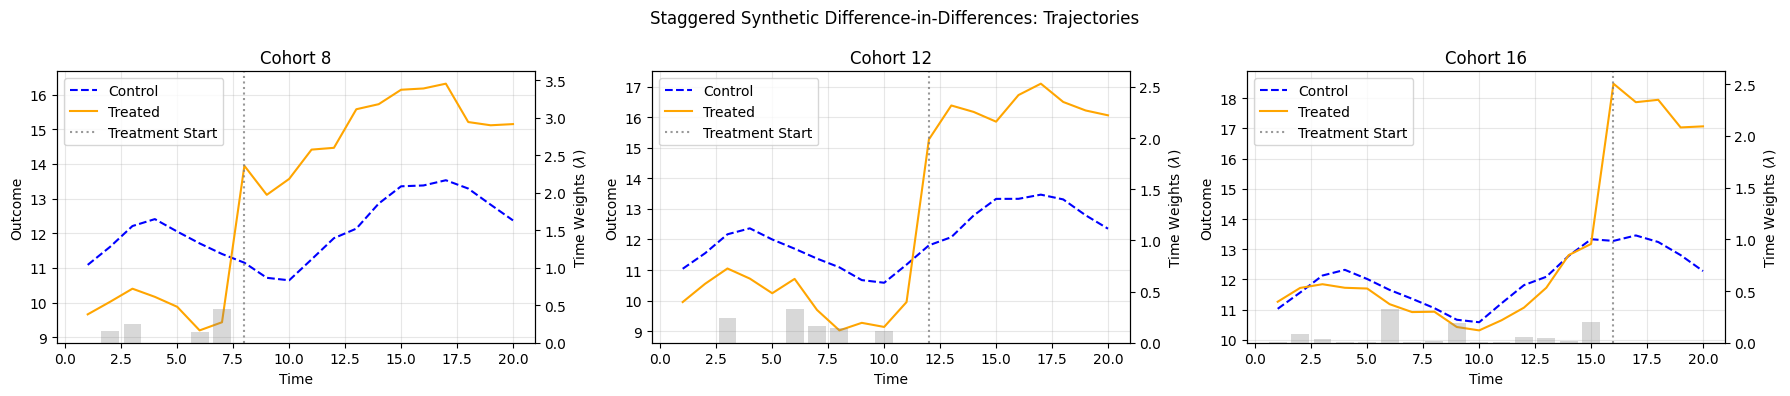

In [15]:
print(model0.ATT)
print(model0.ATT_by_cohort)
model0.plot_all_trajectories()

6.040915090074046
[np.float64(6.557651730131174), np.float64(6.306567118750082), np.float64(5.454123588524173)]


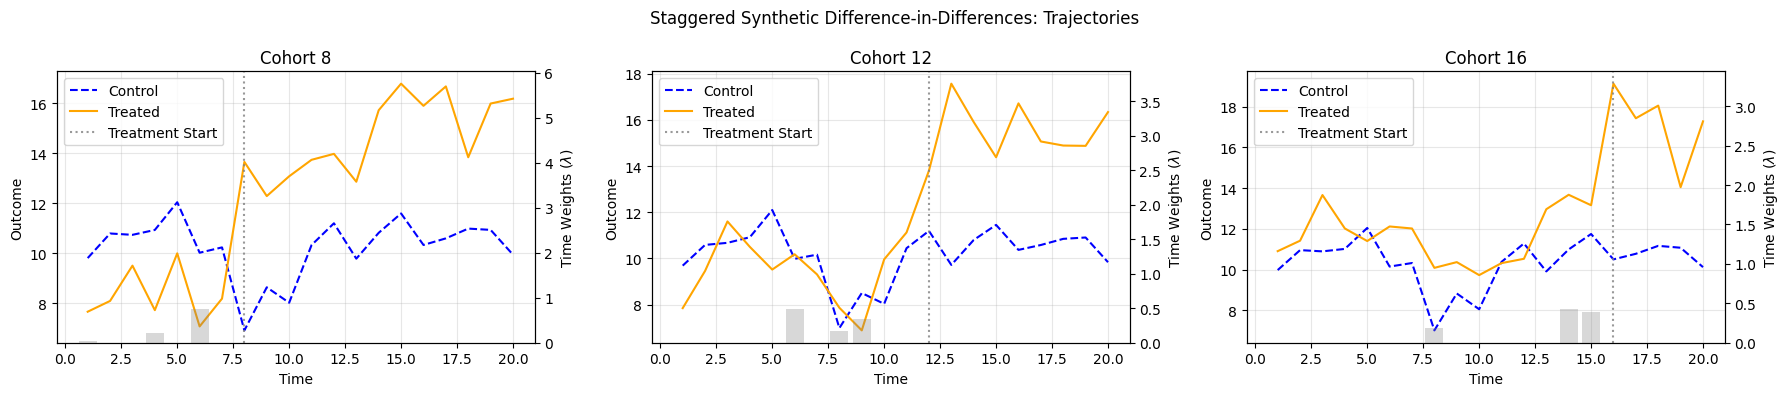

In [16]:
print(model1.ATT)
print(model1.ATT_by_cohort)
model1.plot_all_trajectories()

4.57596170302701
[np.float64(4.348751051895302), np.float64(4.68836187304333), np.float64(4.662069563863553)]


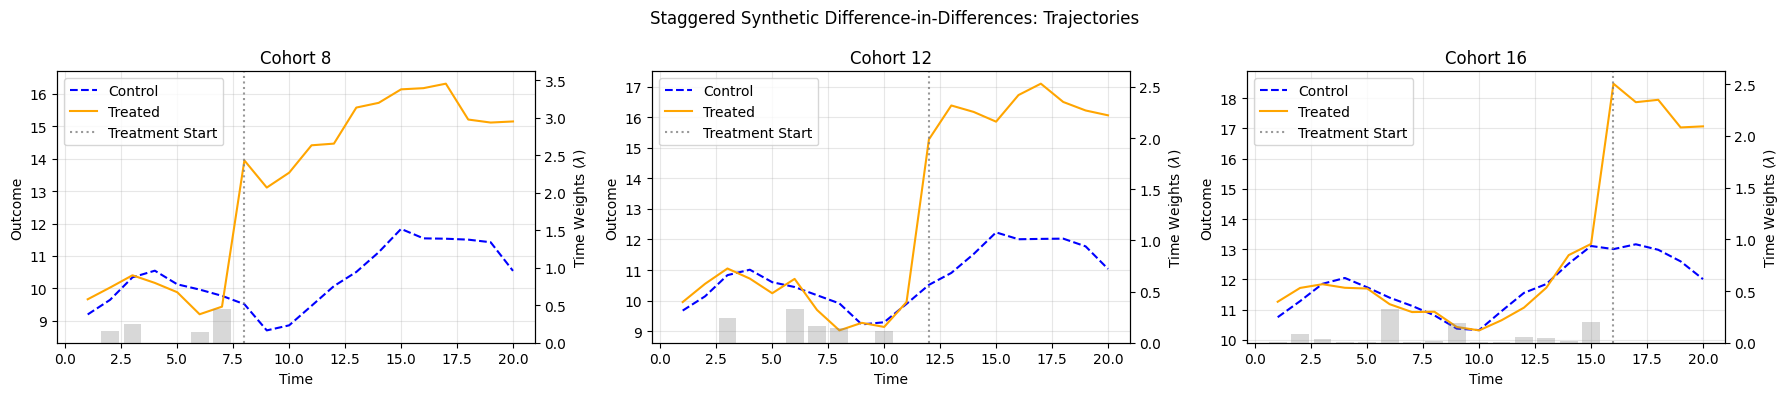

In [17]:
print(model2.ATT)
print(model2.ATT_by_cohort)
model2.plot_all_trajectories()

4.8556035373676325
[np.float64(4.776165229809883), np.float64(4.874423835962096), np.float64(4.901067044090096)]


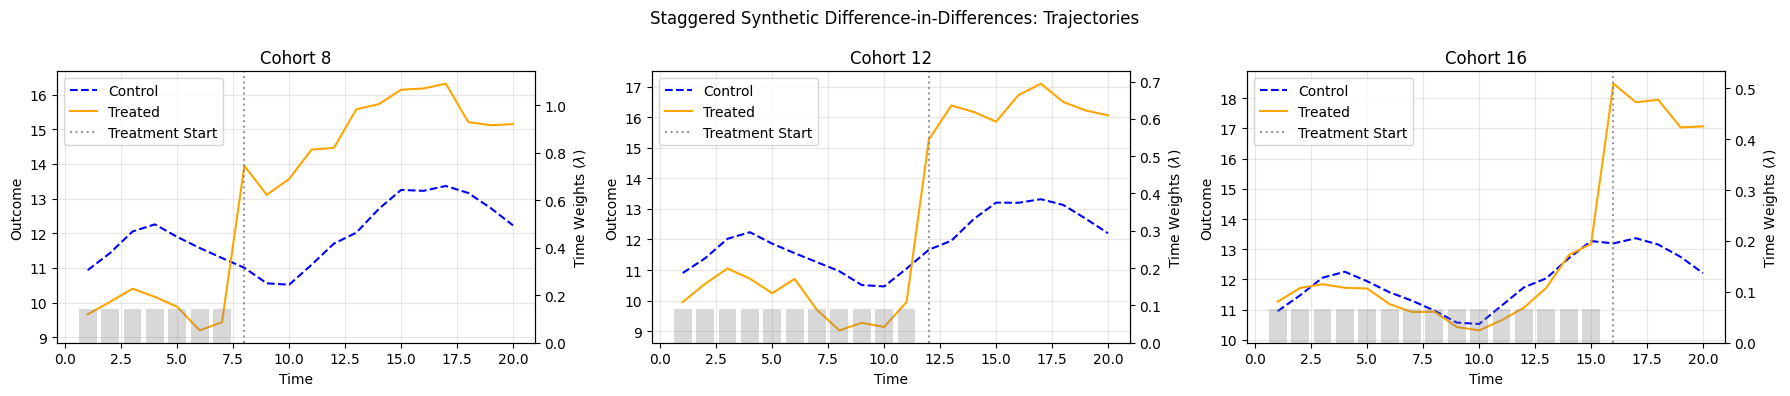

In [18]:
print(model3.ATT)
print(model3.ATT_by_cohort)
model3.plot_all_trajectories()